# Продуктовый анализ поведения пользователей в e-commerce
## Цель проекта
Проанализировать поведение пользователей интернет-магазина косметики, построить пользовательскую воронку, оценить конверсию между этапами, изучить retention и сформулировать продуктовые гипотезы для роста покупок.

## Данные
Используется датасет "eCommerce Events History in Cosmetics Shop" с Kaggle.  
Данные содержат события пользователей интернет-магазина за несколько месяцев: просмотры товаров, добавления в корзину, удаления из корзины и покупки.

In [22]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

###  1. Загрузка данных
Загружаем датасет и проверяем, какие файлы доступны для анализа.

In [ ]:
!{sys.executable} -m pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")

print("Path to dataset files:", path)

In [11]:
print(os.listdir(path))

['2019-Dec.csv', '2019-Nov.csv', '2019-Oct.csv', '2020-Feb.csv', '2020-Jan.csv']


### 2. Первичный обзор данных

Посмотр размера таблицы, типы данных, первые строки и распределение событий.

In [9]:
file_path = os.path.join(path, "2019-Dec.csv")

df = pd.read_csv(file_path)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [ ]:
каждая строка это одно событие пользователя: просмотр, добавление в корзину, удаление из корзины или покупка.

Был выбран один полный месяц данных - декабрь 2019 года. 
Это позволяет сфокусироваться на построении ключевых продуктовых метрик и воронки без усложнения проекта обработкой всех месяцев сразу.

### Ограничение: 
Декабрь может быть сезонным месяцем из-за праздников, поэтому выводы относятся к выбранному периоду и требуют проверки на данных за другие месяцы.

### 2.1 Размер данных и базовая структура

Посмотрим размер таблицы, типы данных, период наблюдения и количество уникальных пользователей, сессий и товаров.

In [14]:
print(f"Количество строк: {df.shape[0]:,}")
print(f"Количество столбцов: {df.shape[1]}")

Количество строк: 3,533,286
Количество столбцов: 9


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 242.6 MB


В данном датасете данные в колонке event_time имеют тип строка, для удобства приведем их к формату datetime.

In [16]:
df["event_time"] = pd.to_datetime(df["event_time"])

print("Начало периода:", df["event_time"].min())
print("Конец периода:", df["event_time"].max())

Начало периода: 2019-12-01 00:00:00+00:00
Конец периода: 2019-12-31 23:59:57+00:00


In [47]:
print(f"Уникальных пользователей: {df['user_id'].nunique()}")
print(f"Уникальных сессий: {df['user_session'].nunique()}")
print(f"Уникальных товаров: {df['product_id'].nunique()}")

Уникальных пользователей: 370154
Уникальных сессий: 839812
Уникальных товаров: 44624


### 2.2 Распределение типов событий

Важно понять, какие действия представлены в данных и как часто они встречаются. Это поможет оценить структуру пользовательского поведения и понять, можно ли строить воронку view -> cart -> purchase.

In [25]:
event_summary = (df["event_type"].value_counts().to_frame("event_count"))
event_summary["share_percent"] = (event_summary["event_count"] / len(df) * 100).round(2)
event_summary

,event_count,share_percent
event_type,,
view,1728331,48.92
cart,927124,26.24
remove_from_cart,664655,18.81
purchase,213176,6.03


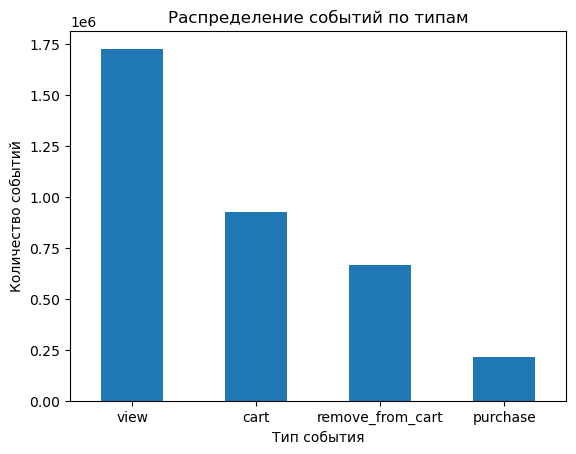

In [24]:
event_summary["event_count"].plot(kind="bar")

plt.title("Распределение событий по типам")
plt.xlabel("Тип события")
plt.ylabel("Количество событий")
plt.xticks(rotation=0)
plt.show()

Всего четыре типа событий: просмотр товара (view), добавление в корзину (cart), удаление из корзины (remove_from_cart) и покупка (purchase).
Почти половина всех событий приходится на просмотры товаров — 48.92%. Добавления в корзину составляют 26.24% событий, удаления из корзины - 18.81%, покупки - 6.03%.

Больше всего событий - просмотры товаров: 48.92%. Это логично, потому что пользователи обычно смотрят больше товаров, чем покупают.

Также видно, что добавлений в корзину довольно много — 26.24%, но удалений из корзины тоже много — 18.81%. Возможно, пользователи добавляют товары в корзину, чтобы сравнить или отложить их, а потом часть товаров удаляют.

Покупки составляют 6.03% всех событий. Но это не значит, что 6.03% пользователей купили товар, потому что здесь считаются именно события. Один пользователь может совершить несколько действий.

Дальше нужно построить воронку по пользователям, чтобы узнать сколько уникальных пользователей посмотрели товар, добавили его в корзину и сделали покупку.

### 2.3 Проверка пропусков

Проверим, есть ли в данных пропущенные значения.  
Для воронки важнее всего, чтобы были заполнены event_time, event_type, user_id и product_id.

In [29]:
print(f"Колво пропусков {df.isna().sum()}") 

Колво пропусков event_time             0
event_type             0
product_id             0
category_id            0
category_code    3474821
brand            1510289
price                  0
user_id                0
user_session         779
dtype: int64


In [30]:
print(f"Доля пропусков в процентах {(df.isna().mean() * 100).round(2)}")

Доля пропусков в процентах event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    98.35
brand            42.74
price             0.00
user_id           0.00
user_session      0.02
dtype: float64


В ключевых полях для анализа пропусков нет. Это значит, что можно строить пользовательскую воронку, считать покупки, выручку и активность пользователей.
В user_session пропусков очень мало — около 0.02%, поэтому эти строки не должны сильно повлиять на анализ сессий.
В brand пропущено 42.74% значений, а в category_code - 98.35%. Поэтому анализ по брендам нужно делать осторожно, а category_code лучше не использовать как основной признак для выводов.

### 2.4 Проверка цен

Перед анализом выручки проверим значения в колонке price: минимальные и максимальные цены, а также наличие нулевых или отрицательных значений.

In [32]:
df["price"].describe()

count    3.533286e+06
mean     8.871856e+00
std      1.986474e+01
min     -7.937000e+01
25%      2.060000e+00
50%      4.210000e+00
75%      7.140000e+00
max      3.277800e+02
Name: price, dtype: float64

In [33]:
print("Отрицательные цены:", (df["price"] < 0).sum())
print("Нулевые цены:", (df["price"] == 0).sum())

Отрицательные цены: 18
Нулевые цены: 7589


В колонке price нашлись 18 отрицательных значений и 7589 нулевых значений. Для анализа выручки такие строки лучше исключить, так как отрицательная или нулевая цена может исказить финансовые метрики.

При этом доля таких строк очень маленькая относительно всего датасета, поэтому фильтрация не должна заметно повлиять на общий анализ. 

In [34]:
df_revenue = df[df["price"] > 0].copy()

In [35]:
print("Строк в исходном df:", len(df))
print("Строк после фильтрации price > 0:", len(df_revenue))
print("Удалено строк:", len(df) - len(df_revenue))

Строк в исходном df: 3533286
Строк после фильтрации price > 0: 3525679
Удалено строк: 7607


Для расчета финансовых метрик я создала отдельную таблицу df_revenue, где оставила только строки с положительной ценой. Это нужно, чтобы нулевые и отрицательные значения не искажали выручку и среднюю цену покупки.

### 2.5 Проверка дубликатов

Проверим, есть ли в данных полностью повторяющиеся строки. Если такие строки есть, они могут завышать количество событий и влиять на расчет метрик.

In [37]:
print(f"Колво дубликатов: {df.duplicated().sum()}")

Колво дубликатов: 183860


In [43]:
df = df.drop_duplicates().copy()

print(f"Количество строк после удаления дубликатов: {len(df)}")

Количество строк после удаления дубликатов: 3349426


In [42]:
df_revenue = df[df["price"] > 0].copy()

В данных нашлось 183 360 полностью повторяющихся строк. Такие строки могут завышать количество событий и финансовые метрики, поэтому я удалила полные дубликаты перед дальнейшим анализом.

После удаления дубликатов я заново создала таблицу df_revenue для расчета финансовых метрик.

## 3. Анализ активности пользователей

Посмотрим, как менялась активность пользователей в течение декабря: сколько было событий, уникальных пользователей и сессий по дням.

In [48]:
df["event_date"] = df["event_time"].dt.date

In [50]:
daily_activity = df.groupby("event_date").agg({
    "event_type": "count",
    "user_id": "nunique",
    "user_session": "nunique"
})

daily_activity.columns = ["events", "users", "sessions"]

daily_activity.head()

,events,users,sessions
event_date,,,
2019-12-01,120086,17540,29616
2019-12-02,127881,19391,31948
2019-12-03,130127,18735,30841
2019-12-04,130403,18836,30422
2019-12-05,120864,18183,29983


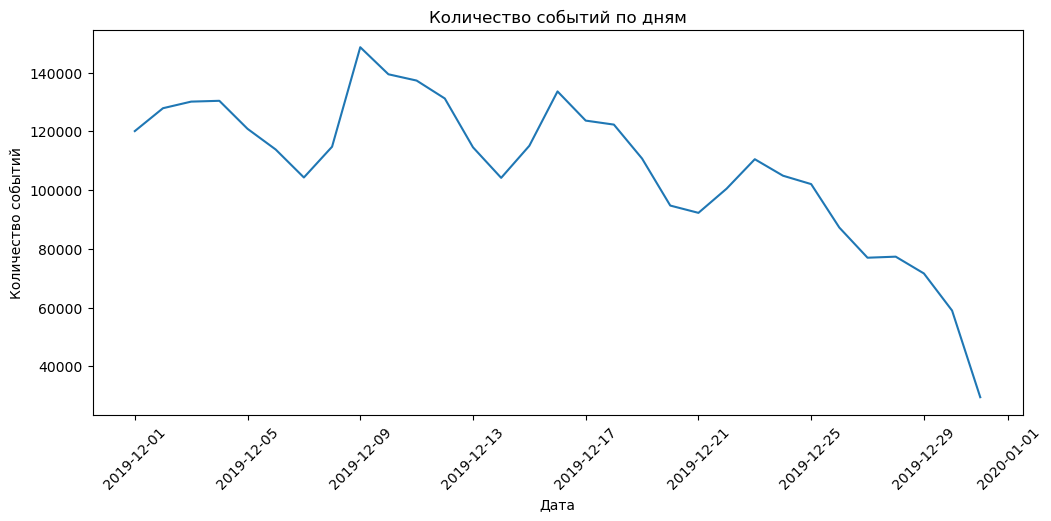

In [51]:
daily_activity["events"].plot(figsize=(12, 5))

plt.title("Количество событий по дням")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.show()

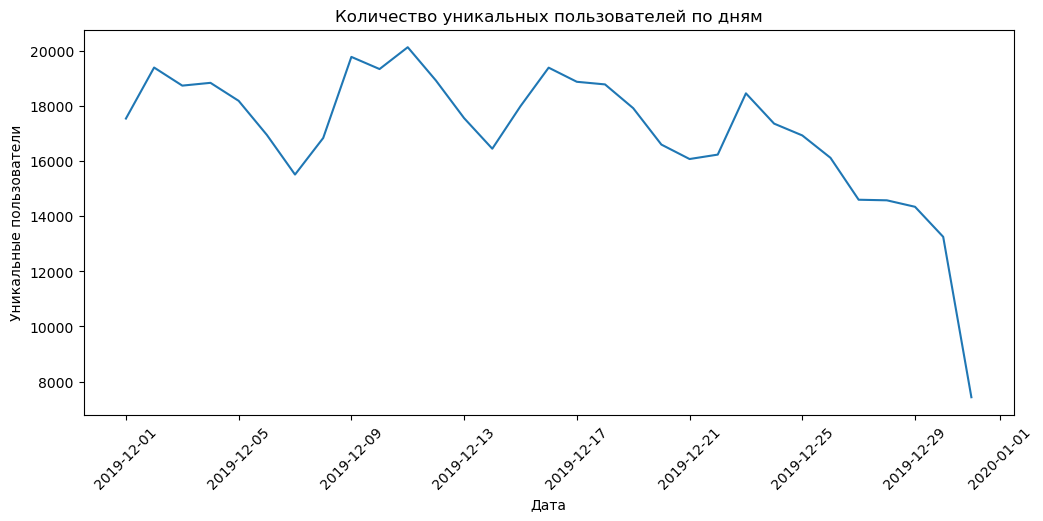

In [52]:
daily_activity["users"].plot(figsize=(12, 5))

plt.title("Количество уникальных пользователей по дням")
plt.xlabel("Дата")
plt.ylabel("Уникальные пользователи")
plt.xticks(rotation=45)
plt.show()

В течение декабря активность пользователей была неравномерной. В первой половине месяца количество событий и уникальных пользователей держалось на более высоком уровне, а после 23–25 декабря заметно снижается.

Падение видно не только по количеству событий, но и по количеству уникальных пользователей. Это значит, что в конце месяца в продукт заходило меньше пользователей, а не просто уменьшилось количество действий на одного пользователя.

Возможная причина снижения - сезонность и праздничный период в конце декабря. Но для подтверждения этой гипотезы нужно сравнить декабрь с другими месяцами или использовать данные о маркетинговых акциях и праздниках. Вероятно перед праздничными днями пользователи выбирали подарки и больше взаимодействовали с продуктом.

### 3.1 Среднее количество событий на пользователя

На предыдущих графиках видно, что в конце месяца снизилось и количество событий, и количество уникальных пользователей.  
Чтобы понять, изменилось ли поведение самих пользователей, посчитаем среднее количество событий на одного пользователя в день.

In [55]:
daily_activity["events_per_user"] = daily_activity["events"] / daily_activity["users"]

daily_activity["events_per_user"].head()

event_date
2019-12-01    6.846408
2019-12-02    6.594864
2019-12-03    6.945663
2019-12-04    6.923073
2019-12-05    6.647088
Name: events_per_user, dtype: float64

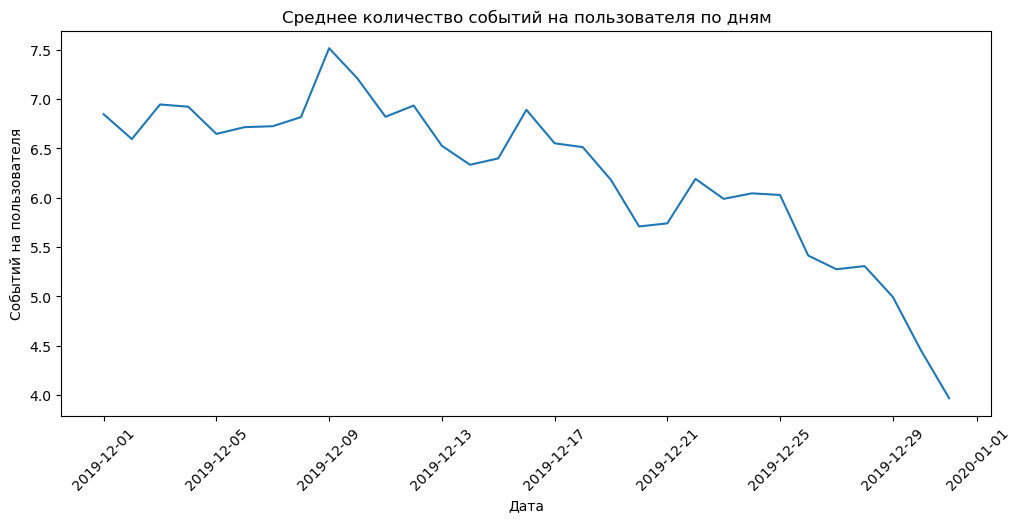

In [61]:
daily_activity["events_per_user"].plot(figsize=(12, 5))

plt.title("Среднее количество событий на пользователя по дням")
plt.xlabel("Дата")
plt.ylabel("Событий на пользователя")
plt.xticks(rotation=45)
plt.show()

Среднее количество событий на пользователя в первой половине месяца держалось примерно на уровне 6.5-7 действий в день. После середины декабря показатель начал снижаться и к концу месяца опустился примерно до 4 действий на пользователя.

Это значит, что падение общего количества событий в конце месяца связано не только с уменьшением числа активных пользователей, но и со снижением активности самих пользователей. Возможное объяснение - сезонность в конце декабря, изменение покупательского поведения или снижение рекламной активности. Для точного объяснения нужны дополнительные данные: другие месяцы, география пользователей или календарь маркетинговых акций.

## 4. Пользовательская воронка

Построим воронку view -> cart -> purchase. Она показывает, сколько пользователей доходит от просмотра товара до добавления в корзину и покупки.

Считать будем уникальных пользователей на каждом этапе, а не количество событий, потому что один пользователь может совершить несколько просмотров или покупок.

In [63]:
funnel = df[df["event_type"].isin(["view", "cart", "purchase"])]

funnel_users = funnel.groupby("event_type")["user_id"].nunique()

funnel_users

event_type
cart         83458
purchase     25613
view        358212
Name: user_id, dtype: int64

In [64]:
funnel_users = funnel_users[["view", "cart", "purchase"]]
funnel_users

event_type
view        358212
cart         83458
purchase     25613
Name: user_id, dtype: int64

In [66]:
view_users = funnel_users["view"]
cart_users = funnel_users["cart"]
purchase_users = funnel_users["purchase"]

view_to_cart = cart_users / view_users * 100
cart_to_purchase = purchase_users / cart_users * 100
view_to_purchase = purchase_users / view_users * 100

print(f"View -> Cart: {view_to_cart:.2f}%")
print(f"Cart -> Purchase: {cart_to_purchase:.2f}%")
print(f"View -> Purchase: {view_to_purchase:.2f}%")

View -> Cart: 23.30%
Cart -> Purchase: 30.69%
View -> Purchase: 7.15%


Воронку я считала по уникальным пользователям, а не по количеству событий. Это важно, потому что один пользователь может несколько раз посмотреть товары или добавить несколько товаров в корзину.

В декабре 358 212 пользователей смотрели товары, 83 458 пользователей добавляли товары в корзину и 25 613 пользователей совершили покупку.

Конверсия из просмотра в корзину составила 23.30%, из корзины в покупку - 30.69%, а общая конверсия из просмотра в покупку - 7.15%.

Самый большой отток пользователей происходит между просмотром товара и добавлением в корзину. Также заметная часть пользователей добавляет товары в корзину, но не завершает покупку. Это может быть связано с ценой, недостатком информации о товаре, условиями доставки или тем, что пользователи используют корзину как список отложенных товаров.

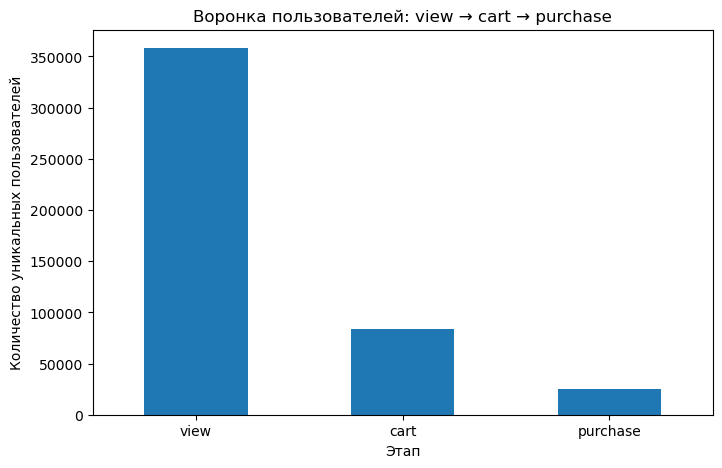

In [68]:
funnel_users.plot(kind="bar", figsize=(8, 5))

plt.title("Воронка пользователей: view → cart → purchase")
plt.xlabel("Этап")
plt.ylabel("Количество уникальных пользователей")
plt.xticks(rotation=0)
plt.show()

## 5. Покупки и выручка

После анализа воронки посмотрим на покупки: сколько покупок было в декабре, какую выручку они принесли и какая была средняя цена покупки.

Для финансовых метрик используем df_revenue, где оставлены только строки с положительной ценой.

In [70]:
purchases = df_revenue[df_revenue["event_type"] == "purchase"]

print("Количество покупок:", len(purchases))
print("Уникальных покупателей:", purchases["user_id"].nunique())
print("Выручка:", round(purchases["price"].sum(), 2))
print("Средняя цена покупки:", round(purchases["price"].mean(), 2))

Количество покупок: 213049
Уникальных покупателей: 25613
Выручка: 1077689.23
Средняя цена покупки: 5.06


В датасете одно событие purchase соответствует покупке конкретного товара. Поэтому количество строк с purchase я интерпретирую как количество купленных товарных позиций, а не как точное количество заказов.

### 5.1 Динамика покупок и выручки по дням

Посмотрим, как менялись количество покупок и выручка в течение месяца.

In [72]:
purchases["event_date"] = purchases["event_time"].dt.date

In [77]:
daily_revenue = purchases.groupby("event_date")["price"].sum()
daily_revenue.head()

event_date
2019-12-01    32686.73
2019-12-02    43271.00
2019-12-03    38682.24
2019-12-04    41207.36
2019-12-05    37353.83
Name: price, dtype: float64

In [78]:
daily_purchases = purchases.groupby("event_date")["price"].count()
daily_purchases.head()

event_date
2019-12-01    7230
2019-12-02    9072
2019-12-03    8212
2019-12-04    8366
2019-12-05    7761
Name: price, dtype: int64

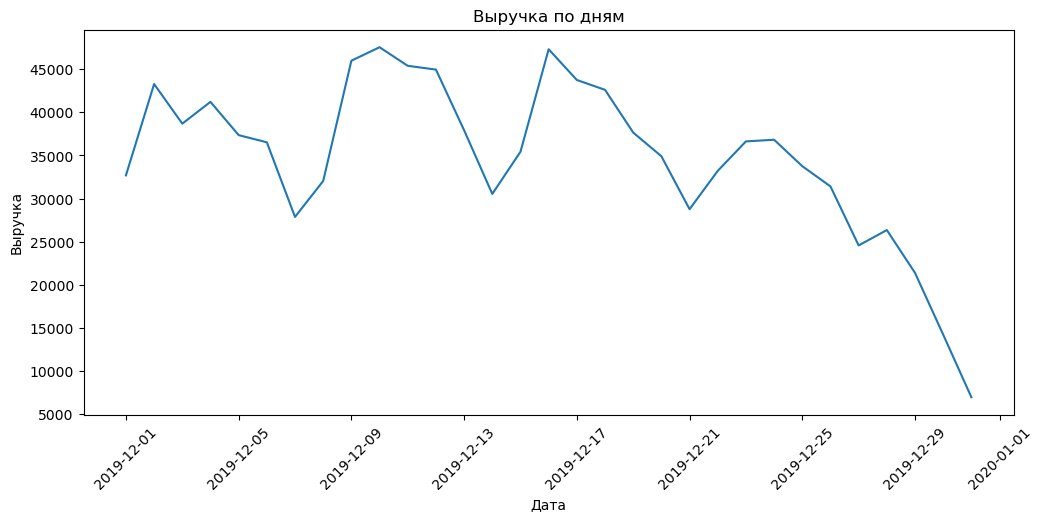

In [79]:
daily_revenue.plot(figsize=(12, 5))

plt.title("Выручка по дням")
plt.xlabel("Дата")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.show()

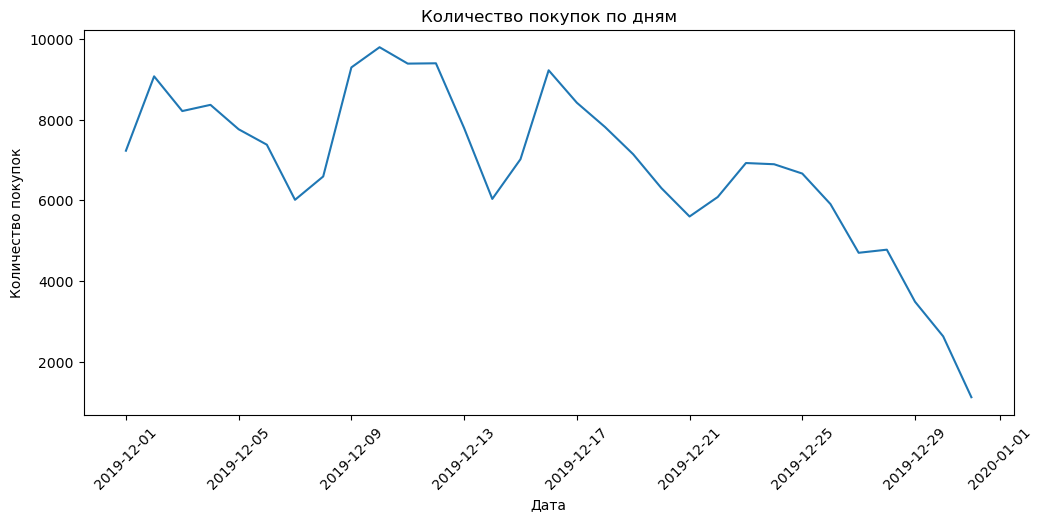

In [80]:
daily_purchases.plot(figsize=(12, 5))

plt.title("Количество покупок по дням")
plt.xlabel("Дата")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)
plt.show()


Чтобы понять, из-за чего менялась выручка, посмотрим не только на количество покупок, но и на среднюю цену покупки по дням.

### 5.2 Средняя цена покупки по дням

In [82]:
daily_avg_price = purchases.groupby("event_date")["price"].mean()

daily_avg_price.head()

event_date
2019-12-01    4.520986
2019-12-02    4.769731
2019-12-03    4.710453
2019-12-04    4.925575
2019-12-05    4.813018
Name: price, dtype: float64

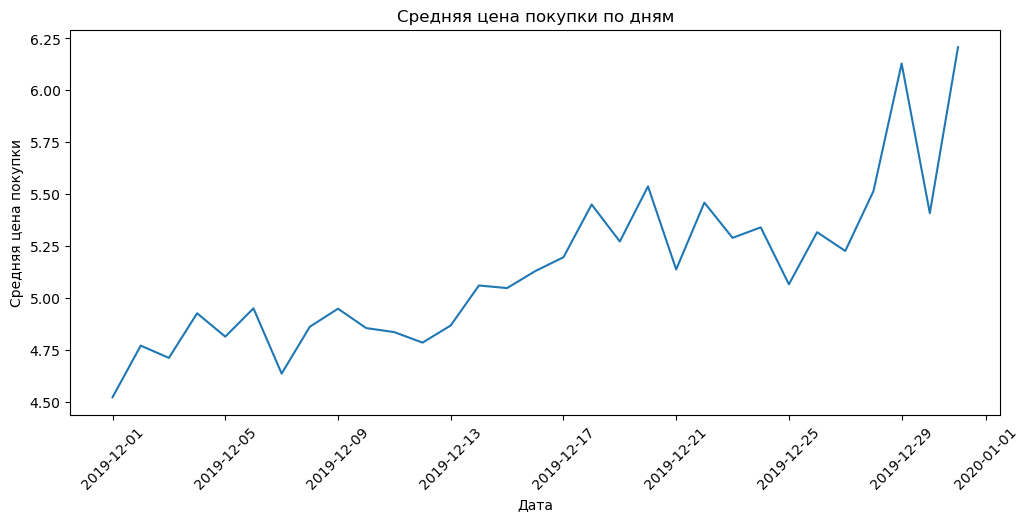

In [83]:
daily_avg_price.plot(figsize=(12, 5))

plt.title("Средняя цена покупки по дням")
plt.xlabel("Дата")
plt.ylabel("Средняя цена покупки")
plt.xticks(rotation=45)
plt.show()

Средняя цена покупки в течение месяца не снижалась. Наоборот, к концу декабря она выросла примерно с 4.5–5 до 6+.

Это значит, что падение выручки в последние дни месяца скорее связано не с тем, что пользователи начали покупать более дешёвые товары, а с уменьшением количества покупок. То есть проблема выглядит как снижение покупательской активности, а не падение среднего чека.

### 5.3 Бренды по выручке

Посмотрим, какие бренды принесли больше всего выручки. Важно учитывать, что в колонке `brand` есть пропуски, поэтому выводы по брендам будут относиться только к товарам, где бренд указан.

In [87]:
brand_revenue = purchases.dropna(subset=["brand"]).groupby("brand")["price"].sum()
brand_revenue = brand_revenue.sort_values(ascending=False)
brand_revenue.head(10)

brand
runail      58173.21
grattol     43793.50
irisk       35289.77
uno         29084.76
estel       24473.32
jessnail    24075.00
strong      22266.41
masura      19669.48
cnd         19378.92
ingarden    18938.21
Name: price, dtype: float64

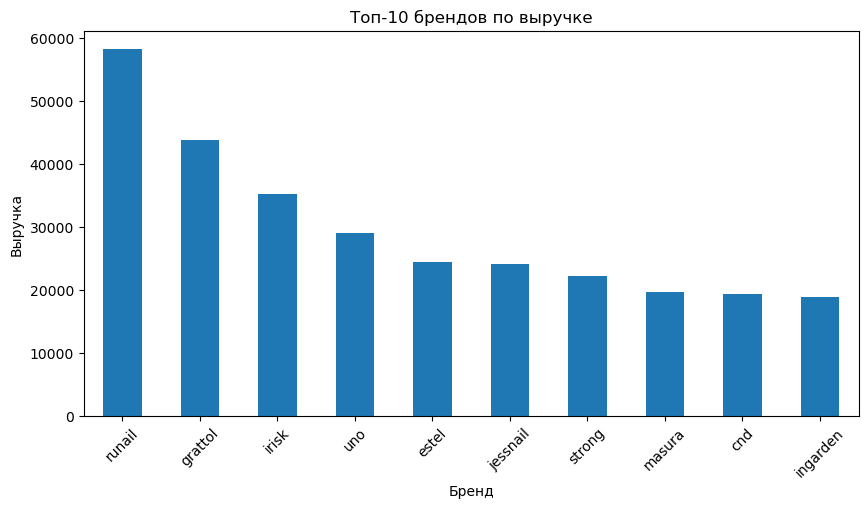

In [88]:
brand_revenue.head(10).plot(kind="bar", figsize=(10, 5))

plt.title("Топ-10 брендов по выручке")
plt.xlabel("Бренд")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.show()

Сложно сделать вывод только по сумме выручки, потому что высокая выручка может быть из-за большого количества покупок или из-за высокой цены. Поэтому для топ-брендов я дополнительно сравнила количество покупок и среднюю цену.

In [89]:
brand_purchases = purchases.dropna(subset=["brand"]).groupby("brand")["price"].count()
brand_purchases = brand_purchases.sort_values(ascending=False)

brand_purchases.head(10)

brand
runail       18198
irisk        10581
grattol       8171
bpw.style     7014
masura        6955
ingarden      4157
estel         4115
kapous        3196
pole          3076
uno           2780
Name: price, dtype: int64

In [91]:
top_brands = brand_revenue.head(10).index

brand_summary = pd.DataFrame({
    "revenue": brand_revenue[top_brands],
    "purchases": brand_purchases[top_brands],
    "avg_price": brand_avg_price[top_brands].round(2)
})

brand_summary

,revenue,purchases,avg_price
brand,,,
runail,58173.21,18198,3.20
grattol,43793.50,8171,5.36
irisk,35289.77,10581,3.34
uno,29084.76,2780,10.46
estel,24473.32,4115,5.95
jessnail,24075.00,1823,13.21
strong,22266.41,120,185.55
masura,19669.48,6955,2.83
cnd,19378.92,1299,14.92


Топ брендов по выручке показывает, что высокая выручка может достигаться разными способами.

runail лидирует по выручке и количеству покупок, но средняя цена покупки у него невысокая. Это похоже на массовый бренд с большим объёмом продаж.

grattol приносит больше выручки, чем irisk, хотя покупок у него меньше. Это связано с более высокой средней ценой покупки.

Также выделяется бренд strong: у него всего 120 покупок, но очень высокая средняя цена, поэтому он попал в топ по выручке. Это показывает, что часть выручки может формироваться не массовыми продажами, а дорогими товарами.

## 7. Retention пользователей
Retention показывает, возвращаются ли пользователи в продукт после первого взаимодействия.  
Посчитаем D1 и D7 retention: долю пользователей, которые вернулись на следующий и седьмой день после первого визита.

In [111]:
# оставляем только пользователя и дату активности
user_dates = df[["user_id", "event_date"]].drop_duplicates()

# первый день активности каждого пользователя
first_dates = user_dates.groupby("user_id")["event_date"].min().reset_index()
first_dates.columns = ["user_id", "first_date"]

# добавляем первый день активности к каждой дате пользователя
user_dates = user_dates.merge(first_dates, on="user_id")

# считаем, через сколько дней после первого визита пользователь был активен
user_dates["event_date"] = pd.to_datetime(user_dates["event_date"])
user_dates["first_date"] = pd.to_datetime(user_dates["first_date"])

user_dates["days_after_first"] = (
    user_dates["event_date"] - user_dates["first_date"]
).dt.days

user_dates.head()

,user_id,event_date,first_date,days_after_first
0,576802932,2019-12-01,2019-12-01,0
1,412120092,2019-12-01,2019-12-01,0
2,494077766,2019-12-01,2019-12-01,0
3,348405118,2019-12-01,2019-12-01,0
4,576005683,2019-12-01,2019-12-01,0


In [112]:
# для D1 берём только пользователей, у которых был шанс вернуться на следующий день
users_for_d1 = first_dates[pd.to_datetime(first_dates["first_date"]) <= pd.to_datetime("2019-12-30")]["user_id"]

d1_users = user_dates[
    (user_dates["user_id"].isin(users_for_d1)) &
    (user_dates["days_after_first"] == 1)
]["user_id"].nunique()

d1_retention = d1_users / users_for_d1.nunique() * 100

print(f"D1 retention: {d1_retention:.2f}%")

D1 retention: 7.36%


In [113]:
# для D7 берём только пользователей, у которых был шанс вернуться через 7 дней
users_for_d7 = first_dates[pd.to_datetime(first_dates["first_date"]) <= pd.to_datetime("2019-12-24")]["user_id"]

d7_users = user_dates[
    (user_dates["user_id"].isin(users_for_d7)) &
    (user_dates["days_after_first"] == 7)
]["user_id"].nunique()

d7_retention = d7_users / users_for_d7.nunique() * 100

print(f"D7 retention: {d7_retention:.2f}%")

D7 retention: 2.60%


D1 retention составил 7.36%, D7 retention - 2.60%.

Это значит, что 7.36% пользователей вернулись в продукт на следующий день после первого визита, а 2.60% на седьмой день.

При расчёте я учитывала только пользователей, у которых была возможность вернуться внутри выбранного периода данных. Например, пользователи, впервые пришедшие в самом конце декабря, не учитывались в расчёте D7 retention.

Retention получился невысоким, но это может быть ожидаемо: пользователи не обязательно заходят в интернет-магазин каждый день. При этом удержание всё равно можно улучшать через рекомендации, напоминания о корзине, акции и персональные предложения.

## 8. Итоговые выводы и продуктовые гипотезы

В проекте был проведён анализ пользовательского поведения в e-commerce за декабрь 2019 года. В данных каждая строка соответствует событию пользователя: просмотру товара, добавлению в корзину, удалению из корзины или покупке.

### Основные выводы

1. После удаления дубликатов в данных осталось более 3 млн пользовательских событий. Ключевые поля для анализа (`event_time`, `event_type`, `user_id`, `product_id`, `price`) заполнены, поэтому данные можно использовать для расчёта основных продуктовых метрик.

2. В конце декабря заметно снижается активность пользователей: падает количество событий, уникальных пользователей и среднее количество событий на пользователя. Возможная причина — сезонность в конце декабря, но для подтверждения нужны данные за другие месяцы, география пользователей или календарь маркетинговых акций.

3. По воронке `view → cart → purchase`:
   - 358 212 пользователей смотрели товары;
   - 83 458 пользователей добавляли товары в корзину;
   - 25 613 пользователей совершили покупку.

4. Конверсия из просмотра в корзину составила 23.30%, из корзины в покупку — 30.69%, а общая конверсия из просмотра в покупку — 7.15%. Самый большой отток происходит между просмотром товара и добавлением в корзину.

5. К концу месяца снижаются количество покупок и выручка. При этом средняя цена покупки растёт, поэтому снижение выручки скорее связано с уменьшением количества покупок, а не с падением среднего чека.

6. Среди брендов с указанным названием больше всего выручки принёс `runail`. Он лидирует и по выручке, и по количеству покупок, то есть выглядит как массовый бренд с большим объёмом продаж. При этом некоторые бренды попадают в топ выручки за счёт высокой средней цены, даже если покупок у них меньше.

7. D1 retention составил 7.36%, D7 retention — 2.60%. Для e-commerce это может быть ожидаемо, так как пользователи не обязательно возвращаются в магазин каждый день. Но удержание всё равно можно улучшать через персональные предложения, рекомендации и коммуникации.